## 12. Diferenças divididas e interpolação de Newton

**Objetivo da aula:** Construir tabelas de diferenças divididas e aplicar a fórmula interpolatória de Newton para aproximar funções a partir de dados tabelados. Comparar com a fórmula de Lagrange e utilizar o esquema recursivo de Horner para avaliar o polinômio interpolador de forma eficiente.

### 12.1 Fórmula de Newton

Seja $f(x)$ definida em $x_0, x_1,...,x_n$, $(n+1)$ pontos distintos de um intervalo $[a,b]$ e $y_i=f(x_i)$, $i=0,1,...,n$. O polinômio interpolador de Newton é dado por 

$$
P_n(x)=f\left[x_0\right]+\sum_{k=1}^n f\left[x_0, x_1, \ldots, x_k\right]\left(x-x_0\right) \ldots\left(x-x_{k-1}\right).
$$

onde $f[x_0]$, $f[x_0,x_1]$,...,$f[x_0,...,x_n]$ são as **diferenças divididas**, definidas como é mostrado a seguir:


**Diferença dividida de ordem 0:**
$$f[x_i]=f(x_i), i=0,1,...,n$$

**Diferença dividida de ordem 1:**
$$f[x_i, x_{i+1}]=\frac{f[x_{i+1}]-f[x_{i}]}{x_{i+1}-x_i}, i=0,1,...,n-1$$

**Diferença dividida de ordem 2:**
$$f[x_i, x_{i+1}, x_{i+2}]=\frac{f[x_{i+1}, x_{i+2}] - f[x_{i}, x_{i+1}]}   {x_{i+2} - x_i}, i=0,1,...,n-2$$

$$\vdots$$

**Diferença dividida de ordem n:**
$$f[x_0,...,x_n]=\frac{f[x_1,...,x_n] - f[x_0, ...,x_{n-1}]}   {x_n - x_0} $$

Para facilitar o cálculo dessas diferenças divididas, é conveniente construir uma tabela em que cada coluna, a partir da terceira, é obtida usando as diferenças entre elementos consecutivos da coluna anterior e valores correspondentes da coluna de $x_i$. Como é mostrado na figura abaixo.

<img src="https://raw.githubusercontent.com/tiagoburiol/MatComp_I/refs/heads/main/12_diferencas_divididas_e_interpolacao_de_newton/figuras/diferencas_divididas.png" width="800">

Figura 12.1 - Tabela de diferenças divididas (Fonte: Burden e Faires, 2016)

A seguir é apresentado um exemplo de como obter as diferenças divididas para um conjunto de 5 pontos distintos da função $f(x)=1/x$. 

**Exemplo 12.1:** Considere os pontos 
\begin{array}{cccccc}
\hline
i   &0     &1    &2     &3     &4     \\ \hline
x_i &1     &2    &4     &5     &8     \\ 
f(x_i) &1.00  &0.50 &0.25  &0.20  &0.125 \\ \hline
\end{array}

Diferenças divididas de ordem 0:

$f[x_0]=f(x_0)=f(1)=1.00$\
$f[x_1]=f(x_1)=f(2)=0.50$\
$f[x_2]=f(x_2)=f(4)=0.25$\
$f[x_3]=f(x_3)=f(5)=0.20$\
$f[x_4]=f(x_4)=f(8)=0.125$

Diferenças divididas de ordem 1:

$f[x_0,x_1]=\frac{f[x_1]-f[x_0]}{x_1-x_0}=\frac{0.5-1}{2-1}=-0.5$\
$f[x_1,x_2]=\frac{f[x_2]-f[x_1]}{x_2-x_1}=\frac{0.25-0.5}{4-2}=-0.125$\
$f[x_2,x_3]=\frac{f[x_3]-f[x_2]}{x_3-x_2}=\frac{0.2-0.25}{5-4}=-0.05$\
$f[x_3,x_4]=\frac{f[x_4]-f[x_3]}{x_4-x_3}=\frac{0.125-0.2}{8-5}=-0.025$

Diferenças divididas de ordem 2:

$f[x_0,x_1,x_2]=\frac{f[x_1,x_2]-f[x_0,x_1]}{x_2-x_0}=\frac{-0.125-(-0.5)}{4-1}=0.125$\
$f[x_1,x_2,x_3]=\frac{f[x_2,x_3]-f[x_1,x_2]}{x_3-x_1}=\frac{-0.05-(-0.125)}{5-2}=0.025$\
$f[x_2,x_3,x_4]=\frac{f[x_3,x_4]-f[x_2,x_3]}{x_4-x_2}=\frac{-0.025-(-0.05)}{8-4}=0.00625$

Diferenças divididas de ordem 3:

$f[x_0,x_1,x_2,x_3]=\frac{f[x_1,x_2,x_3]-f[x_0,x_1,x_2]}{x_3-x_0}=\frac{0.025-0.125}{5-1}=-0.025$\
$f[x_1,x_2,x_3,x_4]=\frac{f[x_2,x_3,x_4]-f[x_1,x_2,x_3]}{x_4-x_1}=\frac{0.00625-0.025}{8-2}=-0.003125$

Diferenças divididas de ordem 4:

$f[x_0,x_1,x_2,x_3,x_4]=\frac{f[x_1,x_2,x_3,x_4]-f[x_0,x_1,x_2,x_3]}{x_4-x_0}=\frac{-0.003125-(-0.025)}{8-1}=0.003125$

Para o Exemplo 12.1 a tabela de diferenças divididas é mostrada a seguir:


$$
\begin{array}{cccccc}
x_i & f[x_i] & f[x_i,x_{i+1}] & f[x_i,\dots,x_{i+2}] & f[x_i,\dots,x_{i+3}] & f[x_i,\dots,x_{i+4}] \\ \hline
1   & 1      & -0.5           & 0.125                & -0.025               & 0.003125             \\
2   & 0.5    & -0.125         & 0.025                & -0.003125            &                     \\
4   & 0.25   & -0.05          & 0.00625              &                      &                     \\
5   & 0.2    & -0.025         &                      &                      &                     \\
8   & 0.125  &                &                      &                      &                     
\end{array}
$$


Observe que as colunas da tabela acima podem ser calculadas de forma bastante prática usando operações vetoriais entre `numpy.arrays`, por exemplo as diferencas divididas de ordem 1 podem ser obtidas fazendo `(f[1:]-f[0:-1])/(x[1:]-x[0:-1])` sendo `x` e `f` _arrays_ contendo os dados de $x_i$ e $f(x_i)$ conforme é mostrado a seguir:

In [44]:
x = np.array([1.,2.,4.,5.,8.])
f = 1/x
(f[1:]-f[0:-1])/(x[1:]-x[0:-1])

array([-0.5  , -0.125, -0.05 , -0.025])

O mesmo resultado pode ser obtido usando a função `diff`:

In [45]:
np.diff(f)/np.diff(x)

array([-0.5  , -0.125, -0.05 , -0.025])

fazendo um laço de repetição para as linhas seguintes podemos obter a tabela de diferenças divididas como é mostrado abaixo:

In [46]:
n = len(x)
for i in range(1,n+1):
    print (f)
    f = (f[1:]-f[0:-1])/(x[i:n]-x[0:n-i])

[1.    0.5   0.25  0.2   0.125]
[-0.5   -0.125 -0.05  -0.025]
[0.125   0.025   0.00625]
[-0.025    -0.003125]
[0.003125]


Por fim, como precisamos apenas do primeiro elemento de cada linha acima, bastaria armazenar os resultados em um único `array`como é mostrado abaixo  

In [47]:
f = 1/x
for i in range(1,n):
    f[i:n] = (f[i:n] - f[i-1])/(x[i:n] - x[i-1])
print (f)

[ 1.       -0.5       0.125    -0.025     0.003125]


Uma vez calculadas as diferenças divididas, usa-se o seguinte método recursivo para avaliar o polinômio em um determinado valor de $x$

$P_0(x) = f[x_0,\dots,x_n]$

$P_1(x) = f[x_0,\dots,x_{n-1}]+ (x-x_{n-1})P_0(x)$

$P_2(x) = f[x_0,\dots,x_{n-2}]+ (x-x_{n-2})P_1(x)$

$\vdots$

$P_n(x) = f[x_0]+ (x-x_0)P_n(x)$


**Exemplo 12.2:** Seja a função $f(x)=e^x\cos(x)\sqrt{x}$ tabelada  nos pontos $x_0=0.0$, $x_1=1.0$, $x_2=2.3$, $x_3=2.5$ e $x_4=4.0$. Vamos usar a fórmula interpolatória de Newton para obter o gráfico do polinômio que interpola esses pontos calculando o valor numérico do polinômio em um conjunto discreto de pontos. Também vamos obter uma forma analítica para esse polinômio usando Python. 

In [75]:
import numpy as np

In [76]:
# Definindo a lista de pontos a serem interpolados
func = lambda x: np.exp(x)*np.cos(x)*np.sqrt(x)
xi = np.array([ 0, 1.0, 2.3, 3.5, 4.0])
yi = func(xi)

In [77]:
# uma função para calcular as diferenças divididas
def diferencas_divididas(x,y):
    m = len(x)
    dd = y.copy()
    for k in range(1,m):
        dd[k:m]=(dd[k:m]-dd[k-1])/(x[k:m]-x[k-1])
    return dd

In [78]:
difs = diferencas_divididas(xi,yi)
print(difs)

[ 0.          1.46869394 -4.50049655 -2.26454299  2.25023479]


In [79]:
def calculaP_Newton(difs,xi,x):
    n = len(xi) - 1
    p = difs[n]
    for i in range(1,n+1):
        p = difs[n-i] + (x -xi[n-i])*p
    return p

Agora, Calculamos o valor do polinômio para diversos pontos para plotarmos um gráfico.

In [80]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(4,3)

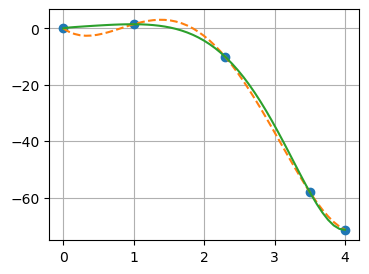

In [81]:
# Cria a lista de pontos para o plot
xp = np.linspace(0, 4, num=51) 
yp = []
for x in xp: 
    yp.append(calculaP_Newton(difs,xi,x))

# Plota
plt.plot(xi, yi, "o")
plt.plot(xp, yp, "--")
plt.plot(xp, func(xp),"-")

plt.grid()
plt.show()

Vamos usar `SymPy` para obter a expressão do polinômio:

In [82]:
import sympy
x = sympy.symbols("x", real=True)

n = len(xi) - 1
p = difs[n]
for i in range(1,n+1):
    p = difs[n-i] + (x -xi[n-i])*p
sympy.expand(p)


2.25023478908295*x**4 - 17.566139553712*x**3 + 34.1382471378265*x**2 - 17.3536484332815*x

**Exemplo 12.3:** Considere a função $f(x)=\frac{x}{(x+1)}$ tabelada  nos pontos $x_0=0,0$, $x_1=1,0$ e $x_2=2,0$. Determine o polinômio interpolador usando a fórmula de Newton e avalie $f(1,3)$. 

In [83]:
xi = np.array([0., 1.0, 2.0])
func = lambda x: np.divide(x, x + 1)
yi = func(xi)


In [84]:
difs = diferencas_divididas(xi,yi)
print (difs)

[ 0.          0.5        -0.16666667]


In [ ]:
print ("P(1,3) =", calculaP_Newton(difs,xi,1.3))

P(1,3) = 0.5850000000000001


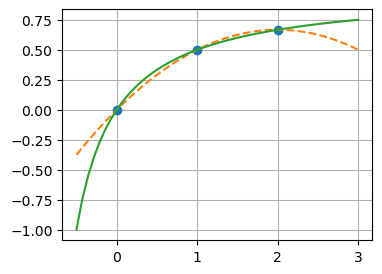

In [86]:
print ("P(1,3) =", calculaP_Newton(difs,xi,1.3))

xp = np.linspace(-0.5, 3)
yp = []

for x in xp:
    yp.append(calculaP_Newton(difs,xi,x))

plt.plot(xi, yi, "o")
plt.plot(xp, yp, "--")
plt.plot(xp, func(xp),"-")

plt.grid()
plt.show()

A biblioteca SciPy para computação científica em Python possui diversos algoritmos para interpolação uni e multidimensional, incluindo _splines_, métodos de Lagrange e baseados em série de Taylor. Veja como fica fácil com o exemplo abaixo.

In [87]:
from scipy.interpolate import lagrange

a = lagrange(xi, yi)
print(a.coef)

[-0.16666667  0.66666667  0.        ]


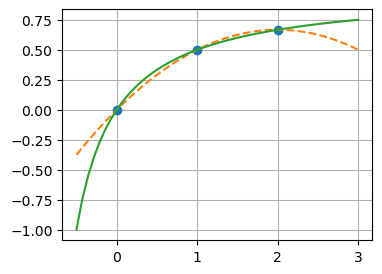

In [88]:
plt.plot(xi, yi, 'o')
plt.plot(xp, np.polyval(a,xp),'--')
plt.plot(xp, func(xp),"-")

plt.grid()
plt.show()

### Exercícios

**1.** Encontre polinômios interpoladores para as funções 

(a) $ln(x+1)$

(b) $\sqrt{1+x}$  

(c) $e^{2x}cos(3x)$ 

no intervalo de $x_0=1$ até $x_n=3$ com $3$, $4$ e $5$ pontos escolhidos arbitrariamente no intervalo.

**2.** Contrua polinômios de grau 3 para os dados a seguir. Faça a aproximação do valor especificado usando cada um dos polinômios e plote o gráfico do polinômio e dos pontos:

a) $f(8,4)$ se $f(8,1)=16,94410, f(8,3)=17,56492, f(8,6)=18,50515, f(8,7)=18,82091$

b) $f(0,9)$ se $f(0,6)=-0,17694460, f(0,7)=0,01375227, f(0,8)=0,22363362, f(1,0)=0,65809197$

c) $f(0,43)$ se $f(0)=1, f(0,25)=1,64872, f(0,5)=2,71828, f(0,75)=4,48169$

d) $f(0)$ se $f(-0,5)=1,93750, f(-0,25)=1,33203, f(0,25)=0,800781, f(0,5)=0,687500$

**3.** Obtenha o polinômio de grau três para os pontos espaçados de forma desigual fornecidos na tabela a seguir e faça o gráfico do polinômio e dos pontos

\begin{array}{c|cccc}
x&    -0,1&     0,0&    0,2&     0,3&  \\ \hline 
f(x)&  5,30&    2,00&   3,19&    1,00&
\end{array}

Acrescente $f(0,35)=0,97260$ à tabela e construa o polinômio interpolador de grau quatro.

**4.** Obtenha o polinômio de grau quatro para os pontos espaçados de forma desigual fornecidos na tabela a seguir e faça o gráfico do polinômio e dos ponto

\begin{array}{c|cccc}
x&    0,03&     0,12&    0,31&     0,62&  1,11&  \\ \hline 
f(x)& -6,123& -5,895&   -5,652&    -5,178& -4,282&
\end{array}
Acrescente $f(1,1)=-3,995$ à tabela e construa o polinômio interpolador de grau cinco.

**5.** O volume específico de um vapor superaquecido está listado nas tabelas de vapor para diversas temperaturas. por exemplo, na pressão absoluta de 3000 lb/pol$^2$:

$$
	\begin{array}{cccccc}
			\hline
			T, ^\circ F &700 &720 &740 &760 &780 \\ \hline
			v, pés^3/lb_m &0,0977 &0,12184 &0,14060 &0,15509 &0,16643  \\
			\hline
		\end{array}
$$	

Use interpolação para obter uma tabela que forneça $v$ a cada 5$^\circ$ entre as temperaturas 720$^\circ$ e 760$^\circ$ usando a fórmula de Newton. 

**6.** Após serem efetuadas medições num gerador de corrente contínua, foram obtidos os seguintes
valores indicados por um voltímetro e um amperímetro.
$$
\begin{array}{ccccccccccccc}
    \hline
I(A) &1.58& 1.75& 2.10& 2.20& 2.50& 3.50& 3.75& 4.25& 4.50& 4.90& 3.12    \\ \hline
V(v) &210& 165& 154& 120& 85& 50& 73& 76& 110& 128& 60		  \\
\hline
\end{array}
$$
Faça um gráfico dos dados.(a) Ajuste os dados por polinômio de grau adequado. (b) Estime o valor a ser obtido no voltímetro quando o amperímetro estiver marcando $4.0A$.

**7.** Dada a tabela a seguir, de valores de uma função $f$,

$$
		\begin{array}{cccccccccc}
			\hline
			x   &0.15&  0.17&  0.19&  0.21&  0.23&  0.25&  0.27\\ \hline
			f(x) &0.1761& 0.2304& 0.2788& 0.3222& 0.3617& 0.3979& 0.4314  \\ \hline
		\end{array}
$$

(a) Utilize todos os pontos para obter uma estimativa para $f(0,22)$ usando um polinômio interpolador com a fórmula de Newton.

(b) Plote o gráfico do polinômio obtido juntamente com os pontos tabelados para verificar o resultado da interpolação.

(c) Escolha 4 pontos e estime $f(0,22)$ utilizando um polinomio de terceiro grau. Plote o gráfico e compare com o resultado do item anterior. Comente.

---
## Questões de múltipla escolha


---
## Questão 1

Considere a função $f(x) = 1/x$ com os pontos $x_0=1$, $x_1=2$, $x_2=4$. Qual é o valor da diferença dividida de ordem 2, $f[x_0, x_1, x_2]$?

a) $-0.250$  
b) $0.125$  
c) $-0.125$  
d) $0.375$  
e) $-0.375$

---
## Questão 2

Uma grande vantagem da fórmula de Newton sobre a de Lagrange é a possibilidade de acrescentar novos pontos sem recalcular tudo. Considere a função $f(x) = e^x$ interpolada inicialmente em $x_0=0, x_1=1, x_2=2$. Ao acrescentar o ponto $x_3=3$, o que acontece com os coeficientes já calculados?

a) Todos os coeficientes anteriores mudam completamente  
b) Apenas o coeficiente $f[x_0]$ muda  
c) Os coeficientes anteriores $f[x_0], f[x_0,x_1], f[x_0,x_1,x_2]$ permanecem inalterados; apenas $f[x_0,x_1,x_2,x_3]$ é novo  
d) Os dois últimos coeficientes mudam  
e) A fórmula de Newton não permite acrescentar pontos

---
## Questão 3

As diferenças divididas têm uma relação com as derivadas da função. Para $f(x) = x^3$, qual é o valor de $f[x_0, x_1, x_2, x_3]$ para **quaisquer** quatro pontos distintos?

a) Depende dos valores específicos de $x_0, x_1, x_2, x_3$  
b) É sempre igual a $6$  
c) É sempre igual a $1$  
d) É sempre igual a $3$  
e) É sempre igual a $0$

---
## Questão 4

Considere os pontos $\{(1, 1), (2, 4), (3, 9), (4, 16)\}$ que pertencem à função $f(x) = x^2$. Usando a fórmula de Newton, qual é o polinômio interpolador? Execute o código e verifique.

a) $P(x) = x^3 - 2x + 1$  
b) $P(x) = x^2$ exatamente  
c) $P(x) = 2x^2 - x - 1$  
d) $P(x) = x^2 + x - 1$  
e) $P(x) = 3x - 2$

---
## Questão 5

A função $f(x) = \ln(x)$ é interpolada nos pontos $x_0=1, x_1=2, x_2=4, x_3=8$ pela fórmula de Newton. Qual é o valor aproximado de $P(3)$, e qual é o erro em relação ao valor exato $\ln(3) \approx 1.0986$?

a) $P(3) \approx 1.25$, erro $\approx 0.15$  
b) $P(3) \approx 1.10$, erro $< 0.01$  
c) $P(3) \approx 0.95$, erro $\approx 0.15$  
d) $P(3) = 1.0986$ exatamente, sem erro  
e) $P(3) \approx 1.06$, erro $\approx 0.04$